# 241: What every alphabet can see, on BCL2/Ced9, P66/CD47 and BHF

Three query proteins, each searched against the same background, the 19_732 canonical
human proteins of GENCODE v49, with all 19 alphabets kmerseek supports:

| case | query | what the right answer is | why it is here |
|---|---|---|---|
| gold standard | Ced9 (*C. elegans*, 280 aa) | BCL2, a known homolog: same SCOP superfamily, structure-verified, under 30% identity | we know the answer, so every metric can be scored on it |
| the reach | P66 (*Borreliella burgdorferi*, 597 aa) | CD47, the proposed partner | a claim that has not been shown; the same scoring says whether any alphabet supports it |
| the application | BHF (*Botryllus schlosseri*, 252 aa) | unknown | the protein the method is for |

Each search writes, for every matched region, the metrics this notebook compares: the
**E-value** (regions this good expected by chance in the whole search, from the
Karlin-Altschul fit on the index), **mean IDF** (how rare the region's k-mers are in the
database), **tf-idf** (the sum of those rarities), **enrichment** (shared k-mers over the
number expected by chance) and the **Poisson p-value** of the shared k-mer count. For the
gold standard and the reach the question is the same under every metric: where does the
known partner rank among all the human proteins that were hit at all?

**Design.** For each alphabet the k ladder is set so one seed carries 16 to 44 bits,
where bits per position is the entropy of the alphabet's class shares measured on this
proteome (`bits_per_position.json`), not log2 of the class count; gbmr7 has 7 classes but
2.0 bits per position because one class holds most residues. Every index is built with
region extension at the alphabet's own optimal mismatch penalty from its measured copy
rate kappa (dark-set `assets/kappa_by_alphabet.tsv`, notebook 230; funcgroups8 has no
kappa and uses 2) and a Karlin-Altschul fit on 200 database sequences, retried with 1_000
sequences and 8 shuffles when refused. When the retry is also refused the search runs
with exact regions, so every metric but the E-value is still computed. Searches keep
every region (`--threshold 0 --min-shared-kmers 1 --max-query-pvalue 1 --min-region-score 0`),
so a rank is over everything, not over a filtered list. The pairwise layer runs
`kmerseek pair` on Ced9/BCL2 and P66/CD47 with no database at all.

Driver: `241_alphabet_ranking_driver.py`. Collector: `241_alphabet_ranking_collect.py`.
Figures: `alphabet_ranking_utils.py`. Data: `/Users/olga/data/botryllus/alphabet-ranking-three-cases/`.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import alphabet_ranking_utils as au

pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(40)

arms, ranks = au.load()
FIG = au.FIG
bits = (
    pl.DataFrame({"alphabet": list(au.CLASSES), "classes": list(au.CLASSES.values())})
    .join(
        pl.DataFrame(
            arms.group_by("alphabet").agg(
                (pl.col("bits") / pl.col("ksize")).first().alias("bits_per_position")
            )
        ),
        on="alphabet",
    )
    .sort("classes", "alphabet")
)
print(
    f"{arms.height} arms over {arms['alphabet'].n_unique()} alphabets; "
    f"{arms.filter(pl.col('searched')).height} searched"
)
print(bits.with_columns(pl.col("bits_per_position").round(3)))

152 arms over 19 alphabets; 152 searched
shape: (19, 3)
┌──────────────────────────┬─────────┬───────────────────┐
│ alphabet                 ┆ classes ┆ bits_per_position │
│ ---                      ┆ ---     ┆ ---               │
│ str                      ┆ i64     ┆ f64               │
╞══════════════════════════╪═════════╪═══════════════════╡
│ hp_kyte_doolittle2       ┆ 2       ┆ 0.937             │
│ hp_lehninger2            ┆ 2       ┆ 1.0               │
│ hp_lehninger_c_nonpolar2 ┆ 2       ┆ 0.999             │
│ hp_pbotc_1st_ed2         ┆ 2       ┆ 0.994             │
│ hp_thomas_dill2          ┆ 2       ┆ 0.966             │
│ hp_thomas_dill_no_c2     ┆ 2       ┆ 0.95              │
│ hp_lehninger_hpc3        ┆ 3       ┆ 1.134             │
│ gbmr4                    ┆ 4       ┆ 1.528             │
│ polarity4                ┆ 4       ┆ 1.784             │
│ wwmj5                    ┆ 5       ┆ 2.197             │
│ dayhoff6                 ┆ 6       ┆ 2.281             │


## 1. Which arms got an E-value

The Karlin-Altschul fit needs four score bins with 30 regions in both the real and the
shuffled curve. Above about 30 bits per seed both curves run short and the fit is
refused; the retry with more queries and shuffles rescues some. An arm without a fit has
every metric but the E-value. Rows in the figure are grouped by how many letters the
alphabet has. Getting a fit is not the same as being able to give a region an E-value:
section 10 is about three alphabets that pass this step and still cannot produce one.

shape: (38, 5)
┌──────────────────────────┬─────────────────────────┬──────┬───────────┬─────────┐
│ alphabet                 ┆ fit                     ┆ arms ┆ from_bits ┆ to_bits │
│ ---                      ┆ ---                     ┆ ---  ┆ ---       ┆ ---     │
│ str                      ┆ str                     ┆ u32  ┆ f64       ┆ f64     │
╞══════════════════════════╪═════════════════════════╪══════╪═══════════╪═════════╡
│ dayhoff6                 ┆ has an E-value          ┆ 4    ┆ 16.0      ┆ 27.0    │
│ dayhoff6                 ┆ no E-value: fit refused ┆ 5    ┆ 32.0      ┆ 43.0    │
│ funcgroups8              ┆ has an E-value          ┆ 1    ┆ 33.0      ┆ 33.0    │
│ funcgroups8              ┆ no E-value: fit refused ┆ 7    ┆ 16.0      ┆ 44.0    │
│ gbmr4                    ┆ has an E-value          ┆ 5    ┆ 15.0      ┆ 32.0    │
│ gbmr4                    ┆ no E-value: fit refused ┆ 3    ┆ 37.0      ┆ 44.0    │
│ gbmr7                    ┆ has an E-value          ┆ 1    ┆

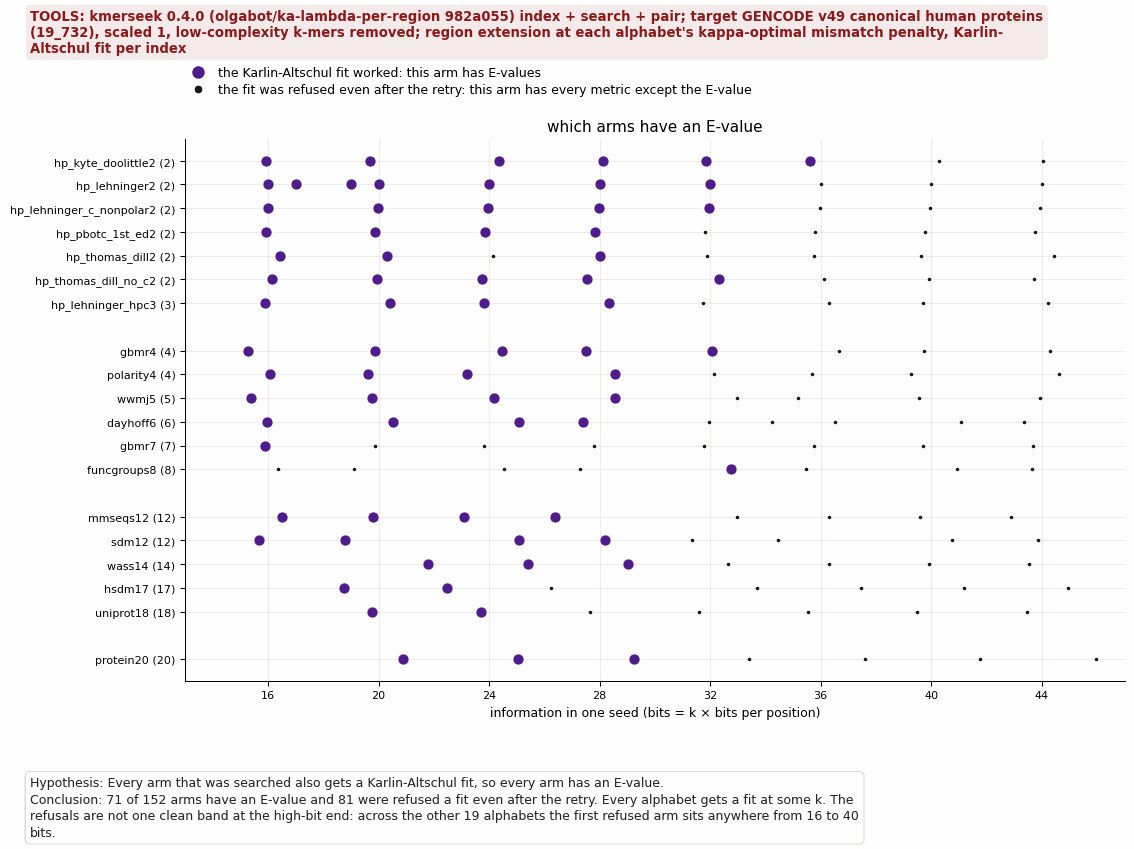

In [2]:
n_fit = arms.filter(pl.col("fitted") == True).height
n_ref = arms.filter(pl.col("fitted") == False).height
n_non = arms.filter(pl.col("fitted").is_null()).height
fit = au.fit_status_figure(
    arms,
    FIG / "241_which_arms_have_an_evalue.png",
    hypothesis="Every arm that was searched also gets a Karlin-Altschul fit, so every arm has an E-value.",
    conclusion=(
        lambda never, part: (
            f"{n_fit} of {arms.height} arms have an E-value and {n_ref} were refused a fit even after the retry. "
            + (
                f"{never.height} alphabets ({', '.join(never['alphabet'])}) are refused at every k they were run at. "
                if never.height
                else "Every alphabet gets a fit at some k. "
            )
            + f"The refusals are not one clean band at the high-bit end: across the other {part.height} alphabets "
            f"the first refused arm sits anywhere from {part['first_refused_bits'].min():.0f} to "
            f"{part['first_refused_bits'].max():.0f} bits."
        )
    )(
        *(
            lambda g: (
                g.filter(pl.col("n_fitted") == 0),
                g.filter((pl.col("n_fitted") > 0) & (pl.col("n_refused") > 0)),
            )
        )(
            arms.filter(pl.col("fitted").is_not_null())
            .group_by("alphabet")
            .agg(
                (pl.col("fitted") == True).sum().alias("n_fitted"),
                (pl.col("fitted") == False).sum().alias("n_refused"),
                pl.col("bits")
                .filter(pl.col("fitted") == False)
                .min()
                .alias("first_refused_bits"),
            )
            .sort("alphabet")
        )
    ),
)
print(fit)
print(
    f"\n{n_fit} arms fitted, {n_ref} refused after the retry (no E-value), {n_non} not run"
)

## 2. The pairwise layer: do the two proteins share any exact k-mer at all?

No database. `kmerseek pair` lists every exact k-mer the two proteins share and the
regions they chain into. A shared k-mer is necessary for a search hit, so this panel is
the ceiling: an alphabet with a grey cross here can never rank the partner anywhere.
For Ced9/BCL2 the black ring marks a shared region inside the BH3-binding groove, the
one place the two proteins are known to align (Ced9 162-181 against BCL2 138-157 in the
first hp_lehninger2 k=17 run; the window is drawn wide at 150-195 / 125-170).

shape: (33, 6)
┌──────────────────────────┬───────┬───────┬────────────────────────┬─────────────────────┬───────────────────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ pair_Ced9_shared_kmers ┆ pair_Ced9_in_window ┆ pair_P66_shared_kmers │
│ ---                      ┆ ---   ┆ ---   ┆ ---                    ┆ ---                 ┆ ---                   │
│ str                      ┆ i64   ┆ f64   ┆ i64                    ┆ bool                ┆ i64                   │
╞══════════════════════════╪═══════╪═══════╪════════════════════════╪═════════════════════╪═══════════════════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ 1                      ┆ false               ┆ 6                     │
│ funcgroups8              ┆ 6     ┆ 16.37 ┆ 11                     ┆ false               ┆ 58                    │
│ funcgroups8              ┆ 7     ┆ 19.1  ┆ 5                      ┆ false               ┆ 16                    │
│ funcgroups8              ┆ 9     ┆ 24.55 ┆ 1           

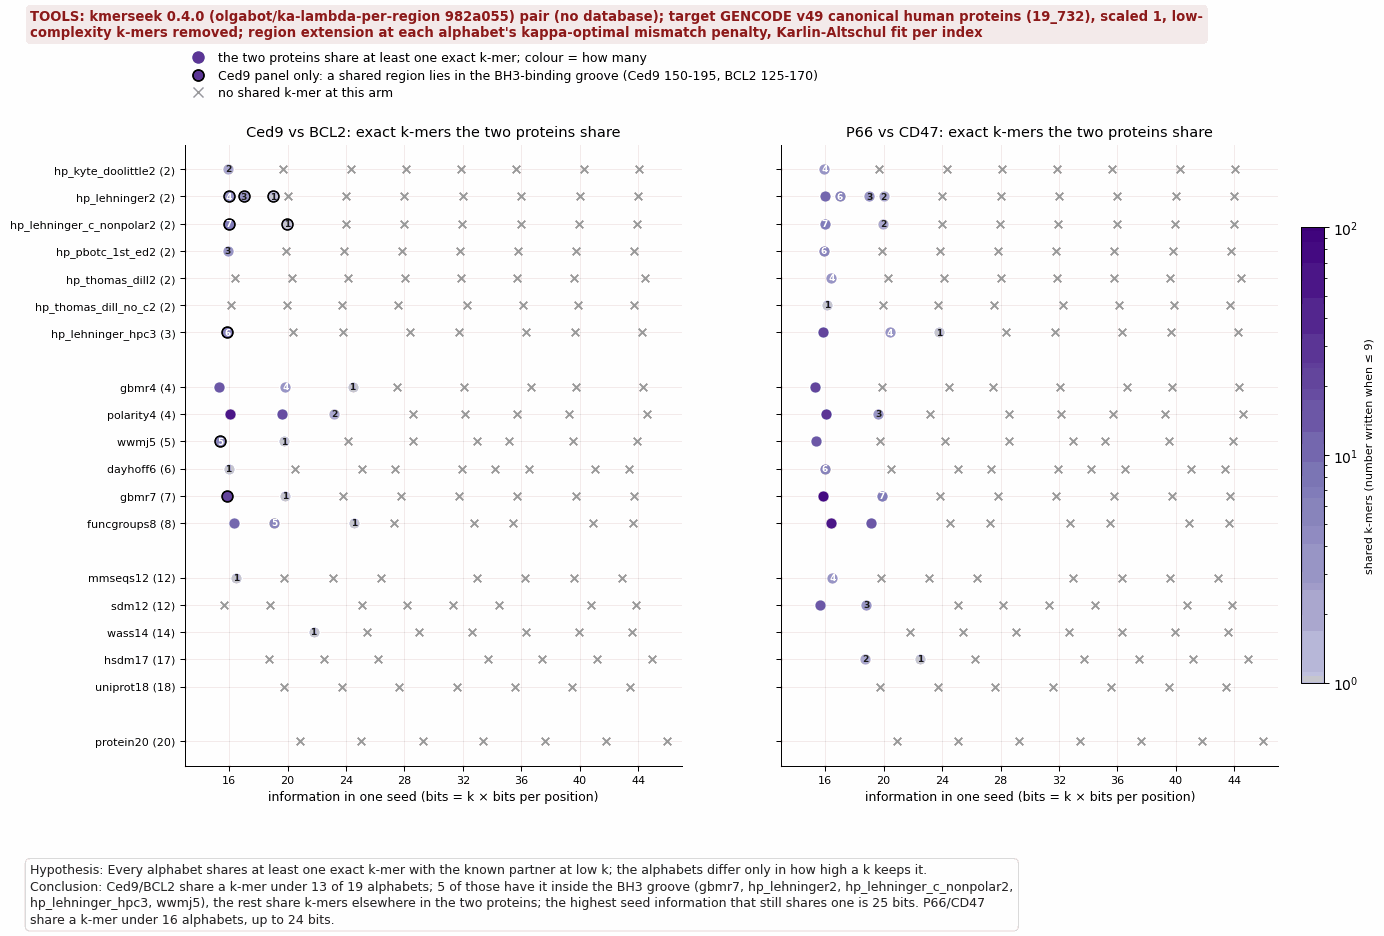

In [3]:
pair_tbl = au.pair_matrix(
    arms,
    FIG / "241_pairwise_shared_kmers.png",
    hypothesis="Every alphabet shares at least one exact k-mer with the known partner at low k; the alphabets differ only in how high a k keeps it.",
    conclusion=(
        lambda t: (
            f"Ced9/BCL2 share a k-mer under {t.filter(pl.col('pair_Ced9_shared_kmers') > 0)['alphabet'].n_unique()} of 19 alphabets; "
            f"{t.filter(pl.col('pair_Ced9_in_window') == True)['alphabet'].n_unique()} of those have it inside the BH3 groove "
            f"({', '.join(sorted(t.filter(pl.col('pair_Ced9_in_window') == True)['alphabet'].unique()))}), the rest share k-mers elsewhere in the two proteins; "
            f"the highest seed information that still shares one is {t.filter(pl.col('pair_Ced9_shared_kmers') > 0)['bits'].max():.0f} bits. "
            f"P66/CD47 share a k-mer under {t.filter(pl.col('pair_P66_shared_kmers') > 0)['alphabet'].n_unique()} alphabets, "
            f"up to {t.filter(pl.col('pair_P66_shared_kmers') > 0)['bits'].max():.0f} bits."
        )
    )(arms),
)
print(
    pair_tbl.filter(
        (pl.col("pair_Ced9_shared_kmers") > 0) | (pl.col("pair_P66_shared_kmers") > 0)
    )
)

## 3. The gold standard: where BCL2 ranks when Ced9 is the query

One dot per arm. Colour is BCL2's rank among every human protein with at least one
region, under that panel's metric; a target's score is its best region. A grey cross
means BCL2 has no region at that arm. A small black dot in the E-value panel means the
arm has no E-value. The number of proteins hit falls with seed information (thousands at 16
bits, a handful at 28), so a rank is only comparable to other ranks at the same arm; the
table under the figure carries the denominator.

shape: (102, 10)
┌──────────────────────────┬───────┬───────┬─────────────────┬───────┬────────┬───────────┬───────────────┬──────────────┬─────────────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ metric          ┆ rank  ┆ n_tied ┆ n_targets ┆ partner_value ┆ best_value   ┆ top_gene        │
│ ---                      ┆ ---   ┆ ---   ┆ ---             ┆ ---   ┆ ---    ┆ ---       ┆ ---           ┆ ---          ┆ ---             │
│ str                      ┆ i64   ┆ f64   ┆ str             ┆ i64   ┆ i64    ┆ i64       ┆ f64           ┆ f64          ┆ str             │
╞══════════════════════════╪═══════╪═══════╪═════════════════╪═══════╪════════╪═══════════╪═══════════════╪══════════════╪═════════════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ Poisson p-value ┆ 16061 ┆ 1      ┆ 16979     ┆ 0.38878       ┆ 5.5511e-16   ┆ TCERG1L         │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ enrichment      ┆ 15908 ┆ 1      ┆ 16979     ┆ 2.031286      ┆ 4869.5       ┆ NBEAL2        

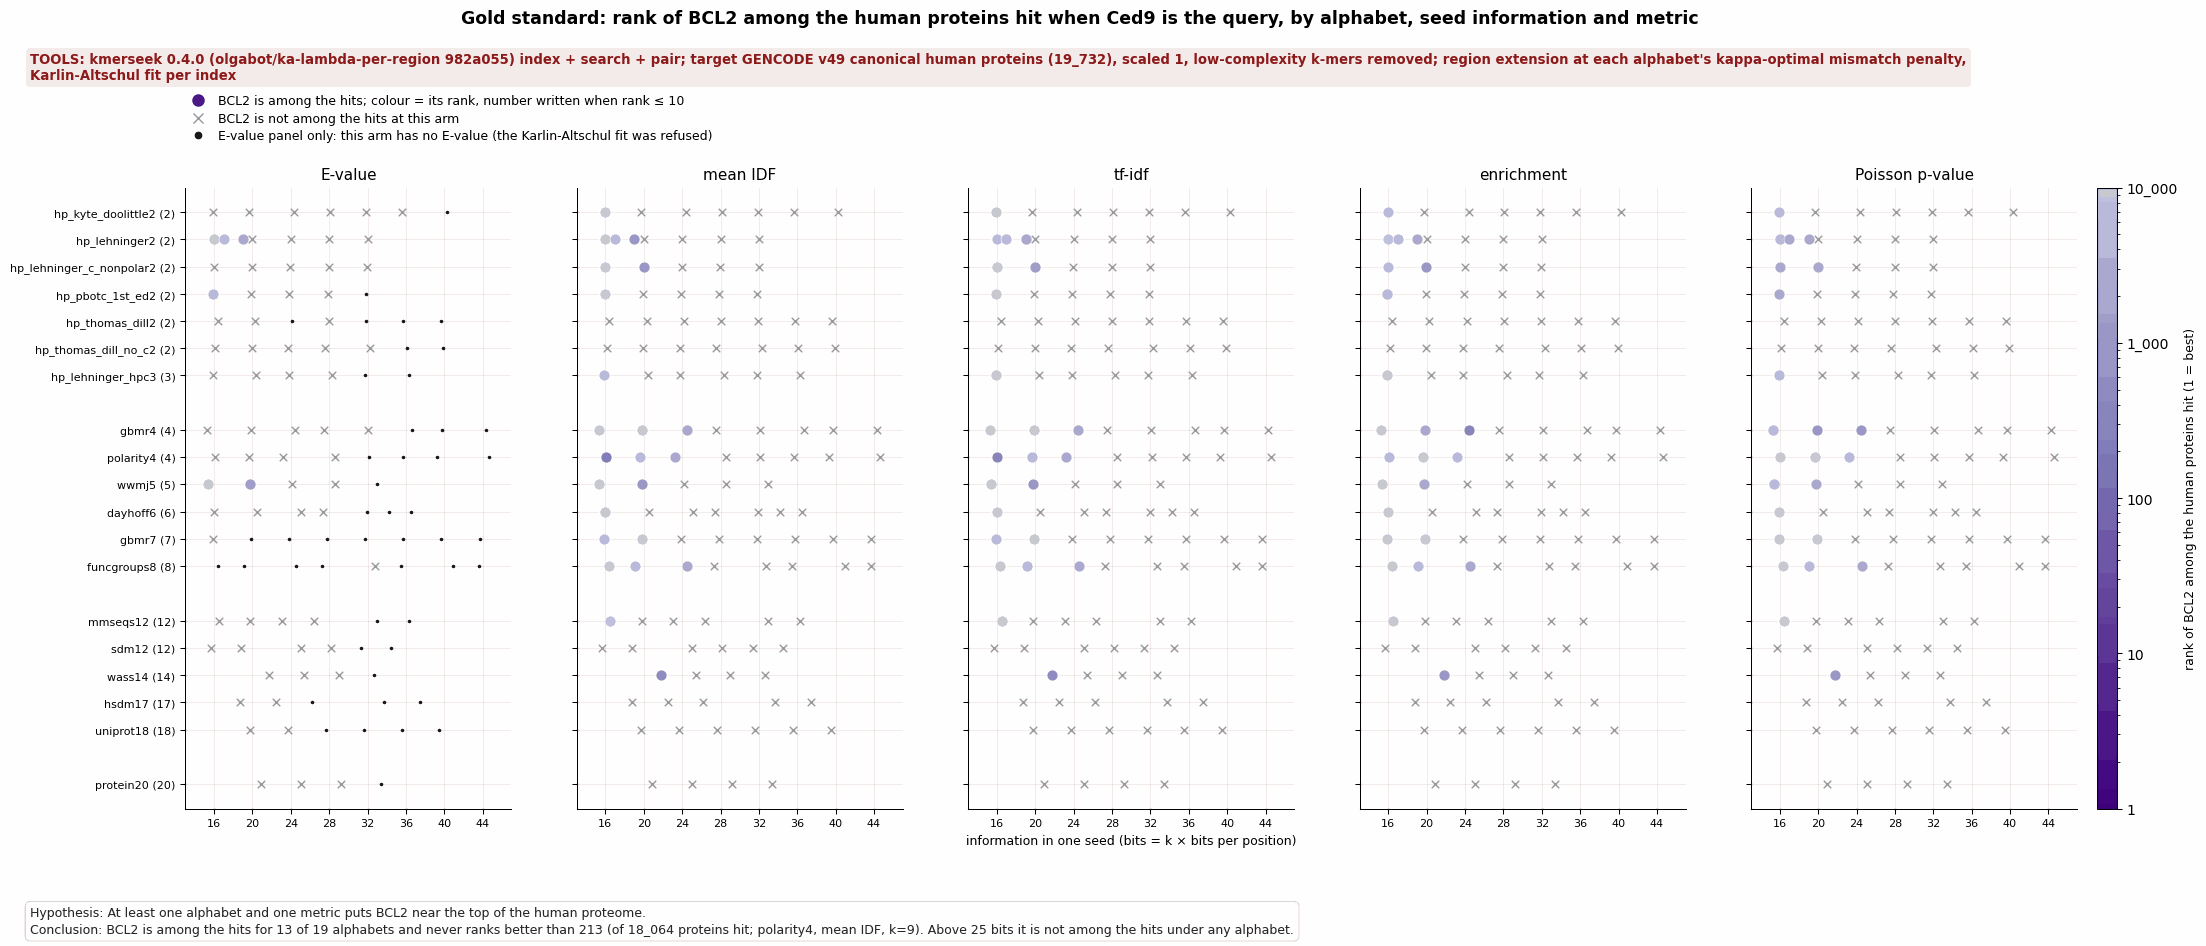

In [4]:
gold = au.rank_matrix(
    ranks,
    arms,
    "Ced9",
    "BCL2",
    FIG / "241_gold_standard_bcl2_rank.png",
    "Gold standard: rank of BCL2 among the human proteins hit when Ced9 is the query, by alphabet, seed information and metric",
    hypothesis="At least one alphabet and one metric puts BCL2 near the top of the human proteome.",
    conclusion=(
        lambda b: (
            f"BCL2 is among the hits for {b.filter(pl.col('rank').is_not_null())['alphabet'].n_unique()} of 19 alphabets and never ranks better than "
            f"{b['rank'].min()} (of {b.filter(pl.col('rank') == b['rank'].min())['n_targets'][0]:_} proteins hit; "
            f"{b.filter(pl.col('rank') == b['rank'].min())['alphabet'][0]}, "
            f"{b.filter(pl.col('rank') == b['rank'].min())['metric'][0]}, k={b.filter(pl.col('rank') == b['rank'].min())['ksize'][0]}). "
            f"Above {b.filter(pl.col('rank').is_not_null())['bits'].max():.0f} bits it is not among the hits under any alphabet."
        )
    )(au.best_per_alphabet(ranks, "Ced9")),
)
print(
    gold.filter(pl.col("partner_found"))
    .select(
        "alphabet",
        "ksize",
        "bits",
        "metric",
        "rank",
        "n_tied",
        "n_targets",
        "partner_value",
        "best_value",
        "top_gene",
    )
    .sort("alphabet", "ksize", "metric")
)

## 4. The reach: where CD47 ranks when P66 is the query

Same layout. CD47 is the proposed partner; nothing here assumes it is right.

shape: (121, 10)
┌──────────────────────────┬───────┬───────┬─────────────────┬───────┬────────┬───────────┬───────────────┬─────────────┬──────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ metric          ┆ rank  ┆ n_tied ┆ n_targets ┆ partner_value ┆ best_value  ┆ top_gene │
│ ---                      ┆ ---   ┆ ---   ┆ ---             ┆ ---   ┆ ---    ┆ ---       ┆ ---           ┆ ---         ┆ ---      │
│ str                      ┆ i64   ┆ f64   ┆ str             ┆ i64   ┆ i64    ┆ i64       ┆ f64           ┆ f64         ┆ str      │
╞══════════════════════════╪═══════╪═══════╪═════════════════╪═══════╪════════╪═══════════╪═══════════════╪═════════════╪══════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ E-value         ┆ 12601 ┆ 21     ┆ 18946     ┆ 37881.842073  ┆ 8.660913    ┆ ARL1     │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ Poisson p-value ┆ 11716 ┆ 14     ┆ 18946     ┆ 0.013513      ┆ 5.3291e-14  ┆ FSTL4    │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ enrichm

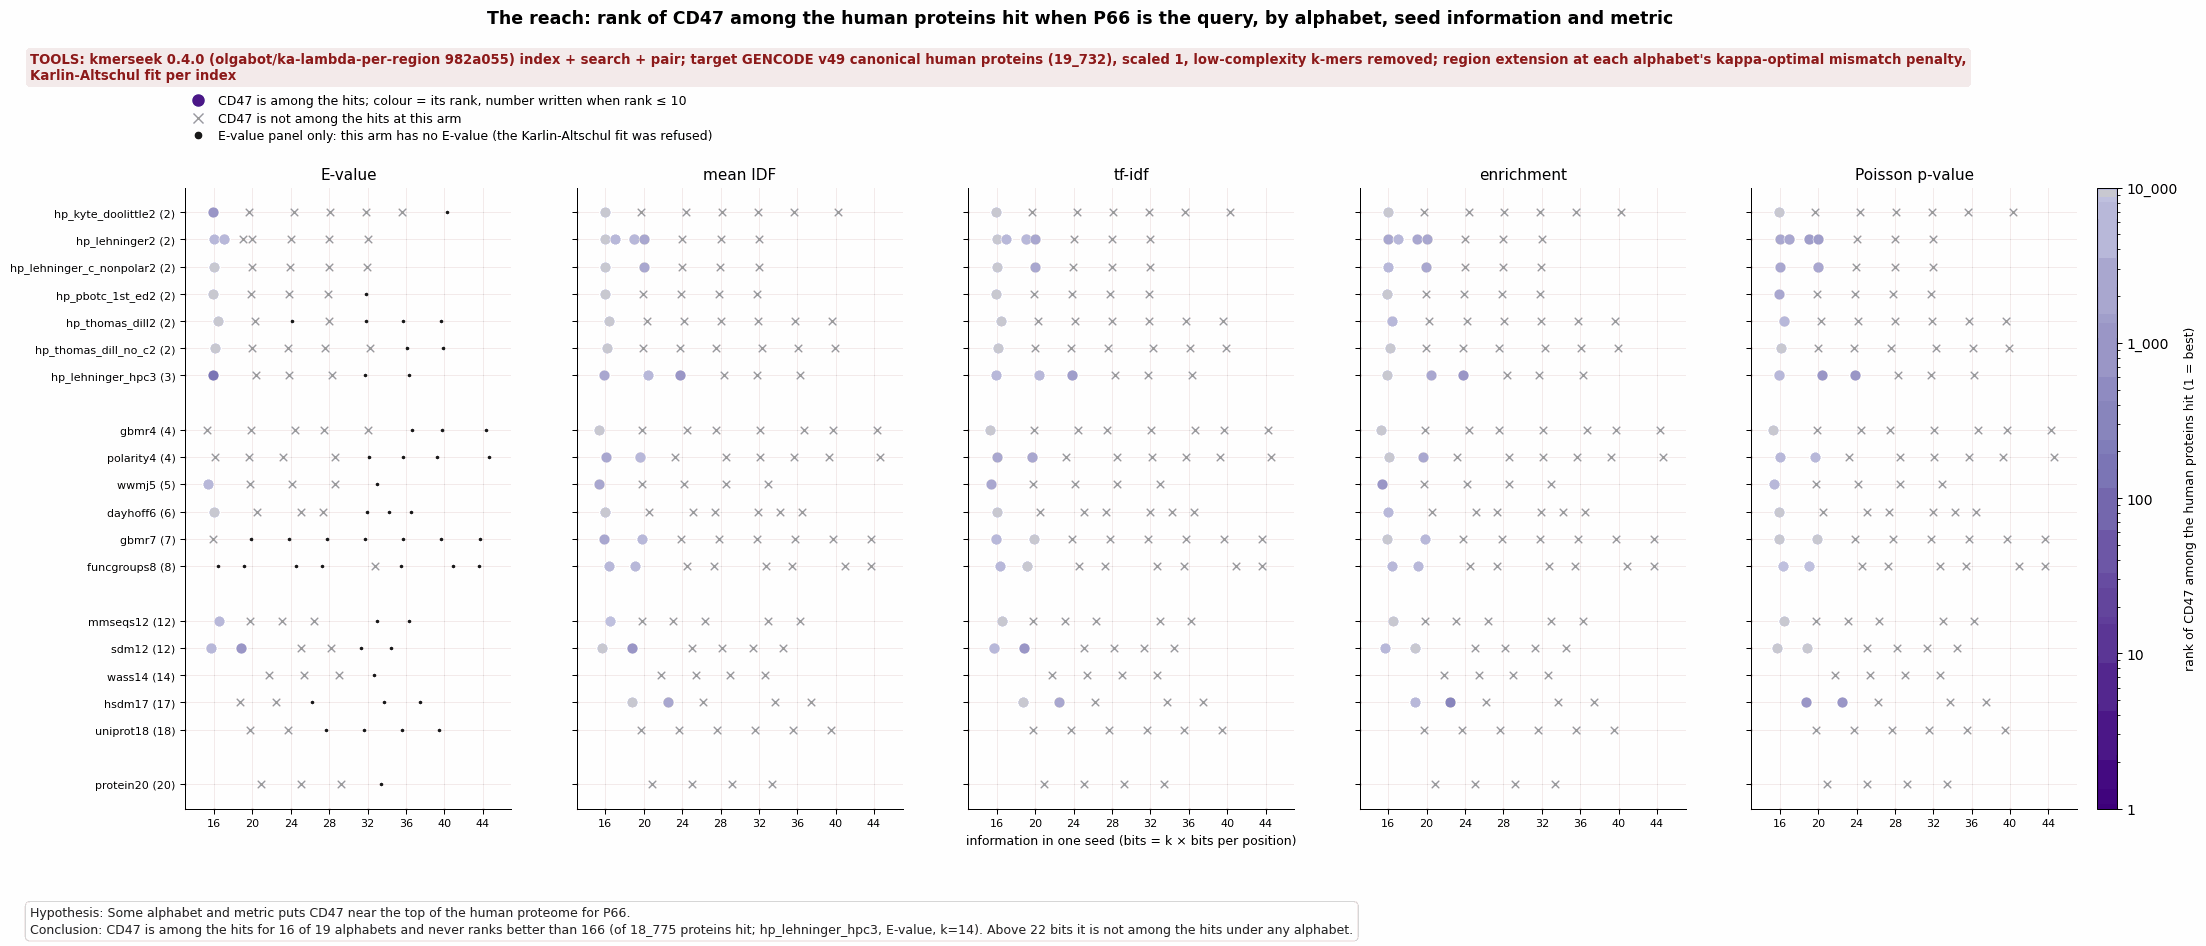

In [5]:
reach = au.rank_matrix(
    ranks,
    arms,
    "P66",
    "CD47",
    FIG / "241_reach_cd47_rank.png",
    "The reach: rank of CD47 among the human proteins hit when P66 is the query, by alphabet, seed information and metric",
    hypothesis="Some alphabet and metric puts CD47 near the top of the human proteome for P66.",
    conclusion=(
        lambda b: (
            f"CD47 is among the hits for {b.filter(pl.col('rank').is_not_null())['alphabet'].n_unique()} of 19 alphabets and never ranks better than "
            f"{b['rank'].min()} (of {b.filter(pl.col('rank') == b['rank'].min())['n_targets'][0]:_} proteins hit; "
            f"{b.filter(pl.col('rank') == b['rank'].min())['alphabet'][0]}, "
            f"{b.filter(pl.col('rank') == b['rank'].min())['metric'][0]}, k={b.filter(pl.col('rank') == b['rank'].min())['ksize'][0]}). "
            f"Above {b.filter(pl.col('rank').is_not_null())['bits'].max():.0f} bits it is not among the hits under any alphabet."
        )
    )(au.best_per_alphabet(ranks, "P66")),
)
print(
    reach.filter(pl.col("partner_found"))
    .select(
        "alphabet",
        "ksize",
        "bits",
        "metric",
        "rank",
        "n_tied",
        "n_targets",
        "partner_value",
        "best_value",
        "top_gene",
    )
    .sort("alphabet", "ksize", "metric")
)

## 5. The best any alphabet does, in one picture

For each alphabet, the best rank the partner reaches over every k and every one of the
five metrics, and which arm and metric got there. This is the one-line answer to "what
can this alphabet see".

shape: (38, 12)
┌──────────────────────────┬─────────┬───────┬────────┬───────────┬───────┬───────┬─────────────────┬───────────────┬─────────────────┬───────────────┬───────┐
│ alphabet                 ┆ classes ┆ rank  ┆ n_tied ┆ n_targets ┆ ksize ┆ bits  ┆ metric          ┆ partner_value ┆ found_from_bits ┆ found_to_bits ┆ query │
│ ---                      ┆ ---     ┆ ---   ┆ ---    ┆ ---       ┆ ---   ┆ ---   ┆ ---             ┆ ---           ┆ ---             ┆ ---           ┆ ---   │
│ str                      ┆ i64     ┆ i64   ┆ i64    ┆ i64       ┆ i64   ┆ f64   ┆ str             ┆ f64           ┆ f64             ┆ f64           ┆ str   │
╞══════════════════════════╪═════════╪═══════╪════════╪═══════════╪═══════╪═══════╪═════════════════╪═══════════════╪═════════════════╪═══════════════╪═══════╡
│ hp_kyte_doolittle2       ┆ 2       ┆ 7624  ┆ 1      ┆ 13945     ┆ 17    ┆ 15.93 ┆ Poisson p-value ┆ 0.015162      ┆ 15.93           ┆ 15.93         ┆ Ced9  │
│ hp_lehninger2         

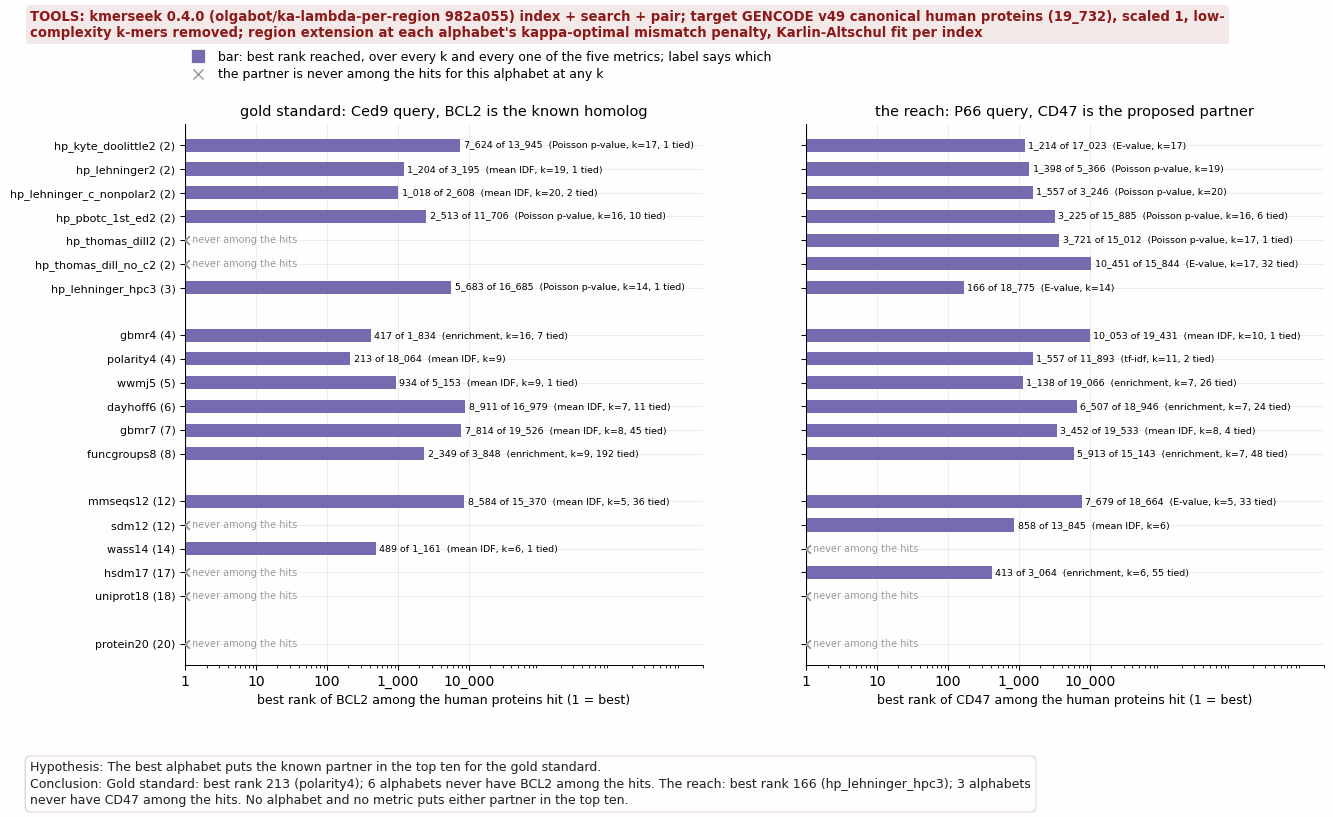

In [6]:
best = au.best_rank_figure(
    ranks,
    FIG / "241_best_rank_per_alphabet.png",
    hypothesis="The best alphabet puts the known partner in the top ten for the gold standard.",
    conclusion=(
        lambda g, r: (
            f"Gold standard: best rank {g['rank'].min()} ({g.filter(pl.col('rank') == g['rank'].min())['alphabet'][0]}); "
            f"{g.filter(pl.col('rank').is_null()).height} alphabets never have BCL2 among the hits. "
            f"The reach: best rank {r['rank'].min()} ({r.filter(pl.col('rank') == r['rank'].min())['alphabet'][0]}); "
            f"{r.filter(pl.col('rank').is_null()).height} alphabets never have CD47 among the hits. "
            f"No alphabet and no metric puts either partner in the top ten."
        )
    )(au.best_per_alphabet(ranks, "Ced9"), au.best_per_alphabet(ranks, "P66")),
)
print(best.sort("query", "classes", "alphabet"))

## 6. Is that better than a human protein picked at random?

A rank of 213 out of 18_064 sounds far from random, but it is the *best* of many tries:
the sweep gives the partner one rank per alphabet, per k and per metric, and section 5
keeps the smallest. The fair comparison keeps the smallest of the same many ranks for a
human protein that is not the partner. A protein that is among the n proteins an arm
hits has, under chance alone, a rank anywhere in 1 to n with equal probability, so
drawing one rank per arm and keeping the smallest says what "best of this sweep" is
worth on its own. 20_000 such draws give the grey range in the figure.

shape: (2, 8)
┌───────┬──────────┬────────────────────┬───────────────────┬─────────────┬──────────┬──────────┬───────────────────────────┐
│ query ┆ n_combos ┆ observed_best_rank ┆ n_targets_at_best ┆ null_median ┆ null_p05 ┆ null_p95 ┆ p_random_at_least_as_good │
│ ---   ┆ ---      ┆ ---                ┆ ---               ┆ ---         ┆ ---      ┆ ---      ┆ ---                       │
│ str   ┆ i64      ┆ i64                ┆ i64               ┆ f64         ┆ f64      ┆ f64      ┆ f64                       │
╞═══════╪══════════╪════════════════════╪═══════════════════╪═════════════╪══════════╪══════════╪═══════════════════════════╡
│ Ced9  ┆ 102      ┆ 213                ┆ 18064             ┆ 42.0        ┆ 4.0      ┆ 176.0    ┆ 0.9743                    │
│ P66   ┆ 121      ┆ 166                ┆ 18775             ┆ 51.0        ┆ 4.0      ┆ 213.05   ┆ 0.90145                   │
└───────┴──────────┴────────────────────┴───────────────────┴─────────────┴──────────┴──────────┴───────

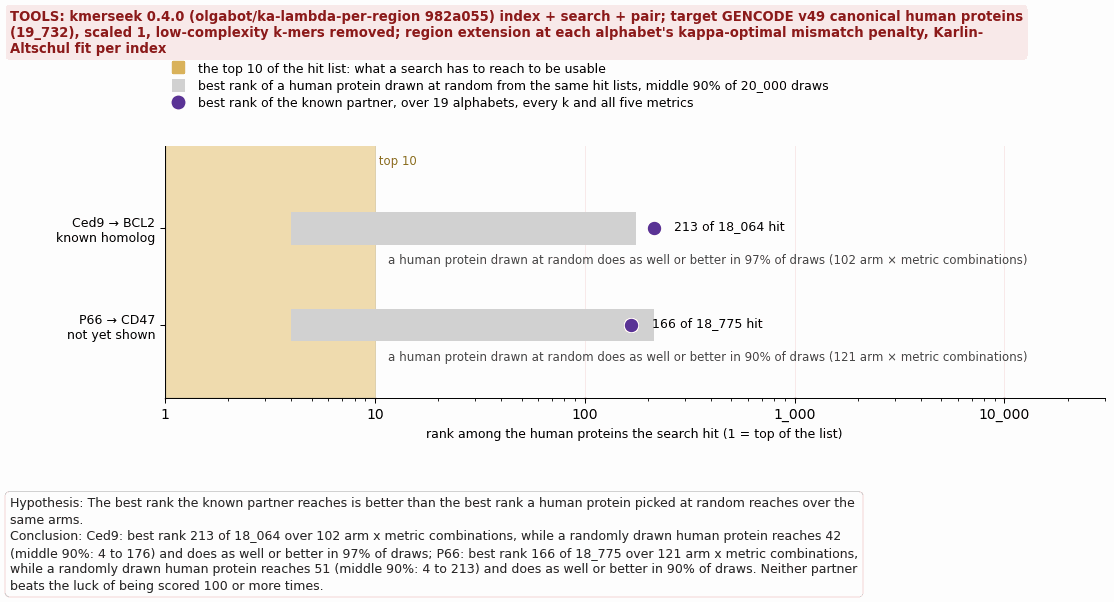

In [7]:
null = au.null_rank_figure(
    ranks,
    FIG / "241_best_rank_vs_random_protein.png",
    hypothesis="The best rank the known partner reaches is better than the best rank a human protein picked at random reaches over the same arms.",
    conclusion=(
        lambda n: "; ".join(
            f"{r['query']}: best rank {r['observed_best_rank']:_} of {r['n_targets_at_best']:_} over {r['n_combos']} arm x metric combinations, "
            f"while a randomly drawn human protein reaches {r['null_median']:.0f} (middle 90%: {r['null_p05']:.0f} to {r['null_p95']:.0f}) "
            f"and does as well or better in {100 * r['p_random_at_least_as_good']:.0f}% of draws"
            for r in n.iter_rows(named=True)
        )
        + ". Neither partner beats the luck of being scored 100 or more times."
    )(pl.DataFrame([au.random_protein_null(ranks, q) for q in ("Ced9", "P66")])),
)
print(null)

### Every metric the search writes, not just the five

Sections 3 to 5 use the five metrics a user would rank on. The search writes six more
(bit score, Poisson score, shared k-mers, containment, protein enrichment, protein
Poisson p-value). Here is the best each one ever does for the known partner, as a
percent of the proteins that arm hit, so a rank of 213 out of 18_064 and a rank of 173
out of 1_161 can be compared. Ties are marked, because a metric that gives thousands of
proteins the same value hands out its rank 1 arbitrarily: `region_ka_bits` did exactly
that until this run, returning 0 for every region of an arm with no lambda and so
putting BCL2 at rank 1 of 18_303 with 18_302 proteins tied. The collector now leaves the
bit score empty where there is no lambda, the same as the E-value.

shape: (22, 8)
┌─────────────────────────┬──────────────┬──────┬───────────┬────────┬───────────────────┬───────┬───────┐
│ metric                  ┆ best_percent ┆ rank ┆ n_targets ┆ n_tied ┆ alphabet          ┆ ksize ┆ query │
│ ---                     ┆ ---          ┆ ---  ┆ ---       ┆ ---    ┆ ---               ┆ ---   ┆ ---   │
│ str                     ┆ f64          ┆ i64  ┆ i64       ┆ i64    ┆ str               ┆ i64   ┆ str   │
╞═════════════════════════╪══════════════╪══════╪═══════════╪════════╪═══════════════════╪═══════╪═══════╡
│ mean IDF                ┆ 1.179141     ┆ 213  ┆ 18064     ┆ 0      ┆ polarity4         ┆ 9     ┆ Ced9  │
│ tf-idf                  ┆ 2.136847     ┆ 386  ┆ 18064     ┆ 0      ┆ polarity4         ┆ 9     ┆ Ced9  │
│ shared k-mers           ┆ 5.379115     ┆ 1023 ┆ 19018     ┆ 863    ┆ gbmr4             ┆ 10    ┆ Ced9  │
│ Poisson p-value         ┆ 13.489209    ┆ 1275 ┆ 9452      ┆ 6      ┆ gbmr4             ┆ 13    ┆ Ced9  │
│ Poisson score       

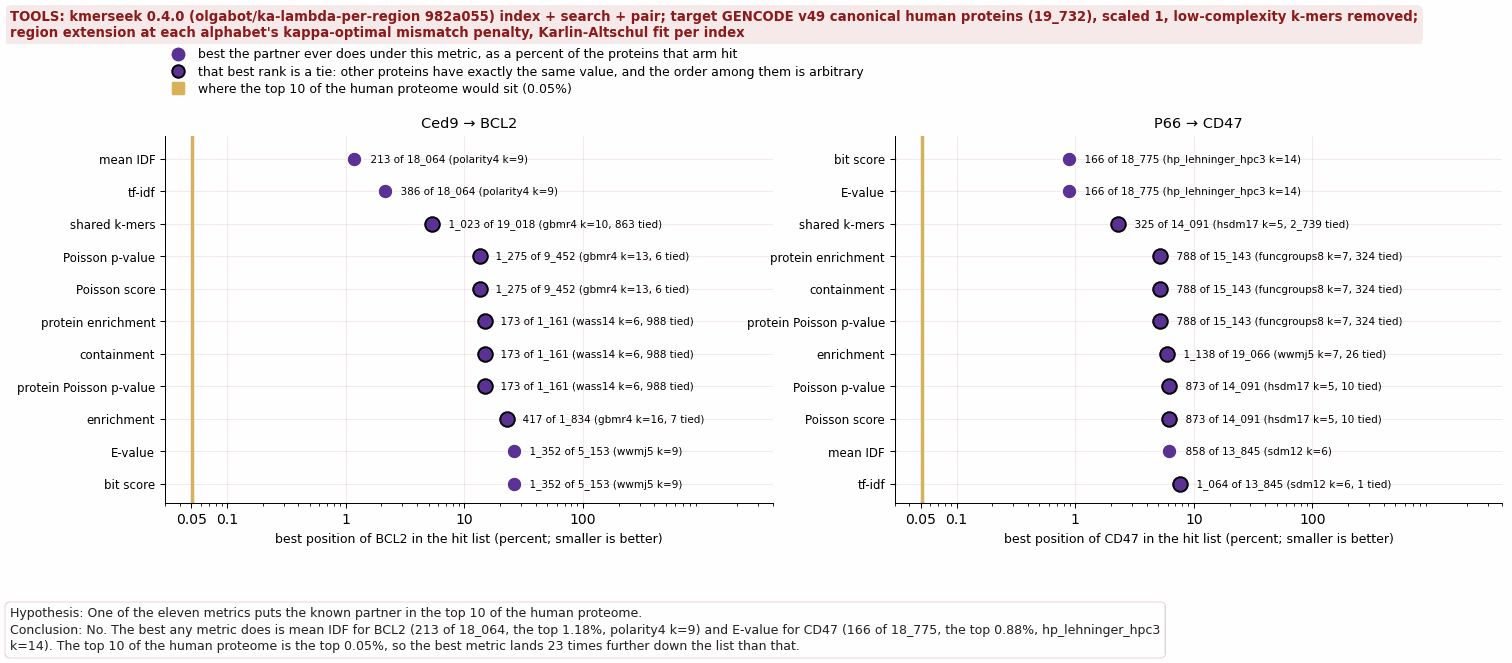

In [8]:
ms = au.metric_sweep_figure(
    ranks,
    FIG / "241_every_metric.png",
    hypothesis="One of the eleven metrics puts the known partner in the top 10 of the human proteome.",
    conclusion=(
        lambda g, r: (
            f"No. The best any metric does is {g['metric'][0]} for BCL2 "
            f"({g['rank'][0]:_} of {g['n_targets'][0]:_}, the top {g['best_percent'][0]:.2f}%, {g['alphabet'][0]} k={g['ksize'][0]}) "
            f"and {r['metric'][0]} for CD47 "
            f"({r['rank'][0]:_} of {r['n_targets'][0]:_}, the top {r['best_percent'][0]:.2f}%, {r['alphabet'][0]} k={r['ksize'][0]}). "
            f"The top 10 of the human proteome is the top {100 * 10 / au.N_HUMAN:.2f}%, so the best metric "
            f"lands {g['best_percent'][0] / (100 * 10 / au.N_HUMAN):.0f} times further down the list than that."
        )
    )(au.best_per_metric(ranks, "Ced9"), au.best_per_metric(ranks, "P66")),
)
print(ms.sort("query", "best_percent"))

## 7. Why: the partner's own E-value against chance

The rank is a symptom. The cause is the amount of evidence in the matched region. Here
is the E-value BCL2 and CD47 themselves get at every arm where they have one. E = 1 means
one region this good is expected by chance somewhere in the search; the ranks above are
what E-values in the thousands look like on a background of 19_732 proteins. The BCL2
region is the BH3 groove, 19 residues of exact HP match that extension grows to 26
residues with 2 mismatches: a 16 to 18 bit score against a database that needs about
32 bits for E = 1.

shape: (19, 7)
┌───────┬──────────────────────────┬───────┬───────┬───────────────┬───────┬───────────┐
│ query ┆ alphabet                 ┆ ksize ┆ bits  ┆ partner_value ┆ rank  ┆ n_targets │
│ ---   ┆ ---                      ┆ ---   ┆ ---   ┆ ---           ┆ ---   ┆ ---       │
│ str   ┆ str                      ┆ i64   ┆ f64   ┆ f64           ┆ i64   ┆ i64       │
╞═══════╪══════════════════════════╪═══════╪═══════╪═══════════════╪═══════╪═══════════╡
│ Ced9  ┆ wwmj5                    ┆ 9     ┆ 19.77 ┆ 1954.636333   ┆ 1352  ┆ 5153      │
│ Ced9  ┆ hp_pbotc_1st_ed2         ┆ 16    ┆ 15.91 ┆ 10209.467342  ┆ 5558  ┆ 11706     │
│ Ced9  ┆ hp_lehninger2            ┆ 19    ┆ 19.0  ┆ 11172.693332  ┆ 2040  ┆ 3195      │
│ Ced9  ┆ hp_lehninger2            ┆ 17    ┆ 17.0  ┆ 29481.880667  ┆ 6101  ┆ 8883      │
│ Ced9  ┆ hp_lehninger2            ┆ 16    ┆ 16.0  ┆ 45097.582252  ┆ 9301  ┆ 12691     │
│ Ced9  ┆ wwmj5                    ┆ 7     ┆ 15.38 ┆ 73372.702995  ┆ 11359 ┆ 18363     │
│ P66 

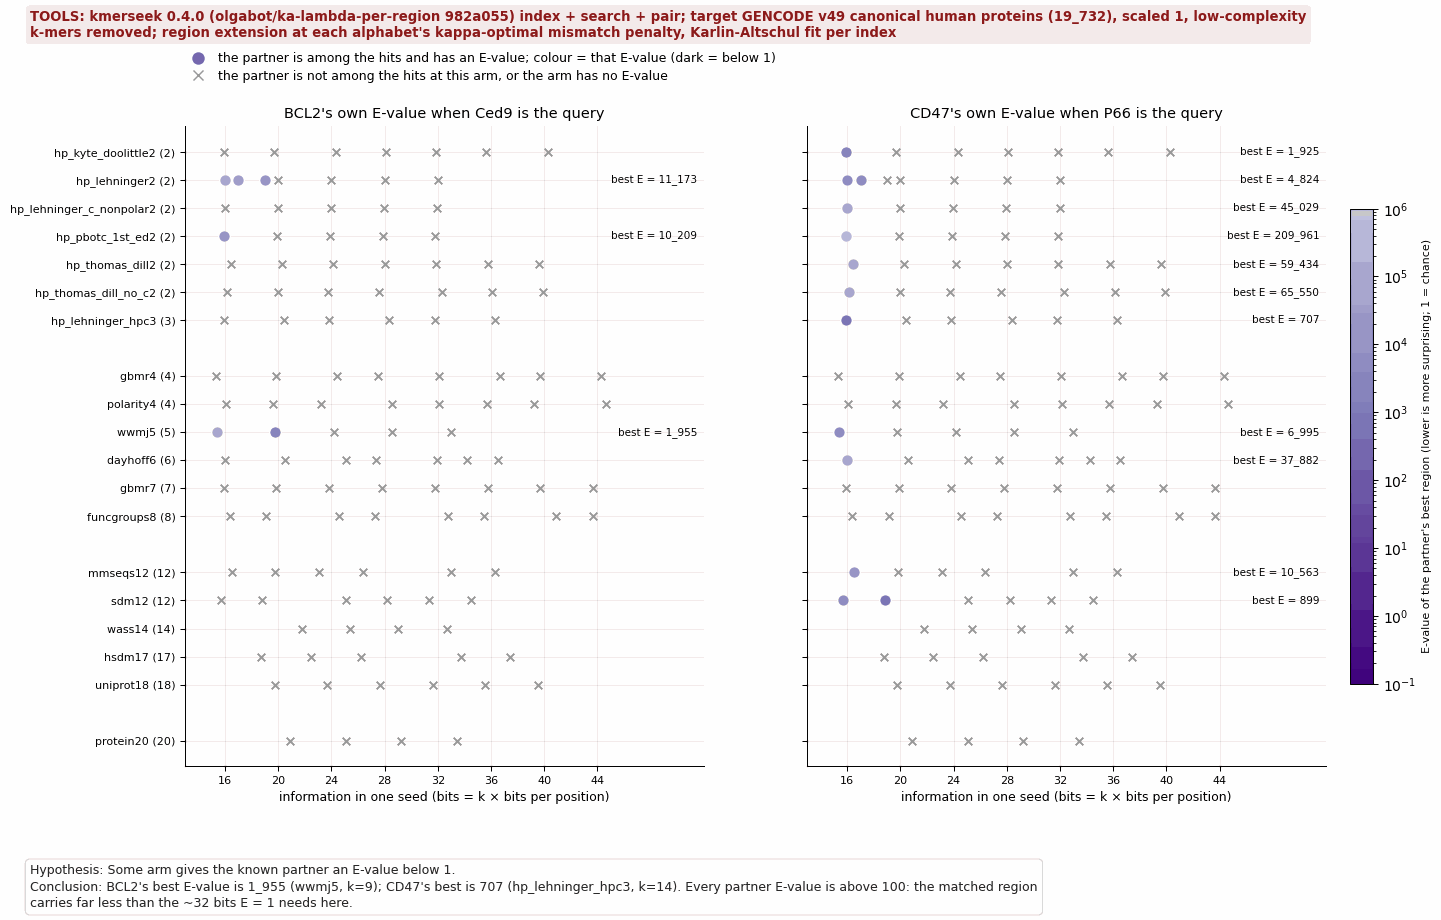

In [9]:
pe = au.partner_evalue_figure(
    ranks,
    arms,
    FIG / "241_partner_evalue_vs_chance.png",
    hypothesis="Some arm gives the known partner an E-value below 1.",
    conclusion=(
        lambda t: (
            f"BCL2's best E-value is {t.filter(pl.col('query') == 'Ced9')['partner_value'].min():_.0f} "
            f"({t.filter(pl.col('query') == 'Ced9').sort('partner_value')['alphabet'][0]}, "
            f"k={t.filter(pl.col('query') == 'Ced9').sort('partner_value')['ksize'][0]}); "
            f"CD47's best is {t.filter(pl.col('query') == 'P66')['partner_value'].min():_.0f} "
            f"({t.filter(pl.col('query') == 'P66').sort('partner_value')['alphabet'][0]}, "
            f"k={t.filter(pl.col('query') == 'P66').sort('partner_value')['ksize'][0]}). "
            f"Every partner E-value is above 100: the matched region carries far less than the ~32 bits E = 1 needs here."
        )
    )(
        ranks.filter((pl.col("metric") == "E-value") & pl.col("partner_found"))
        .join(arms.select("alphabet", "ksize", "fitted"), on=["alphabet", "ksize"])
        .filter(pl.col("fitted") == True)
    ),
)
print(pe.sort("query", "partner_value"))

## 8. The application: what BHF gets

BHF has no known partner, so the two panels show what any alphabet returns: the best
E-value of any human protein (left; a black ring where it is below 1, with the gene
named) and how many human proteins have at least one region (right).

shape: (40, 7)
┌──────────────────────────┬───────┬───────┬────────┬───────────────┬────────────┬──────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ fitted ┆ n_targets_BHF ┆ best_value ┆ top_gene │
│ ---                      ┆ ---   ┆ ---   ┆ ---    ┆ ---           ┆ ---        ┆ ---      │
│ str                      ┆ i64   ┆ f64   ┆ bool   ┆ i64           ┆ f64        ┆ str      │
╞══════════════════════════╪═══════╪═══════╪════════╪═══════════════╪════════════╪══════════╡
│ polarity4                ┆ 13    ┆ 23.2  ┆ true   ┆ 772           ┆ 0.609548   ┆ SCN10A   │
│ hp_lehninger_c_nonpolar2 ┆ 28    ┆ 27.97 ┆ true   ┆ 16            ┆ 0.844149   ┆ SFI1     │
│ gbmr7                    ┆ 8     ┆ 15.88 ┆ true   ┆ 19427         ┆ 0.990939   ┆ FXYD5    │
│ hp_lehninger_c_nonpolar2 ┆ 16    ┆ 15.98 ┆ true   ┆ 10143         ┆ 1.34456    ┆ MIEF1    │
│ hp_lehninger2            ┆ 28    ┆ 28.0  ┆ true   ┆ 11            ┆ 1.85407    ┆ SFI1     │
│ hp_thomas_dill2          ┆ 17    ┆ 16.42 ┆ 

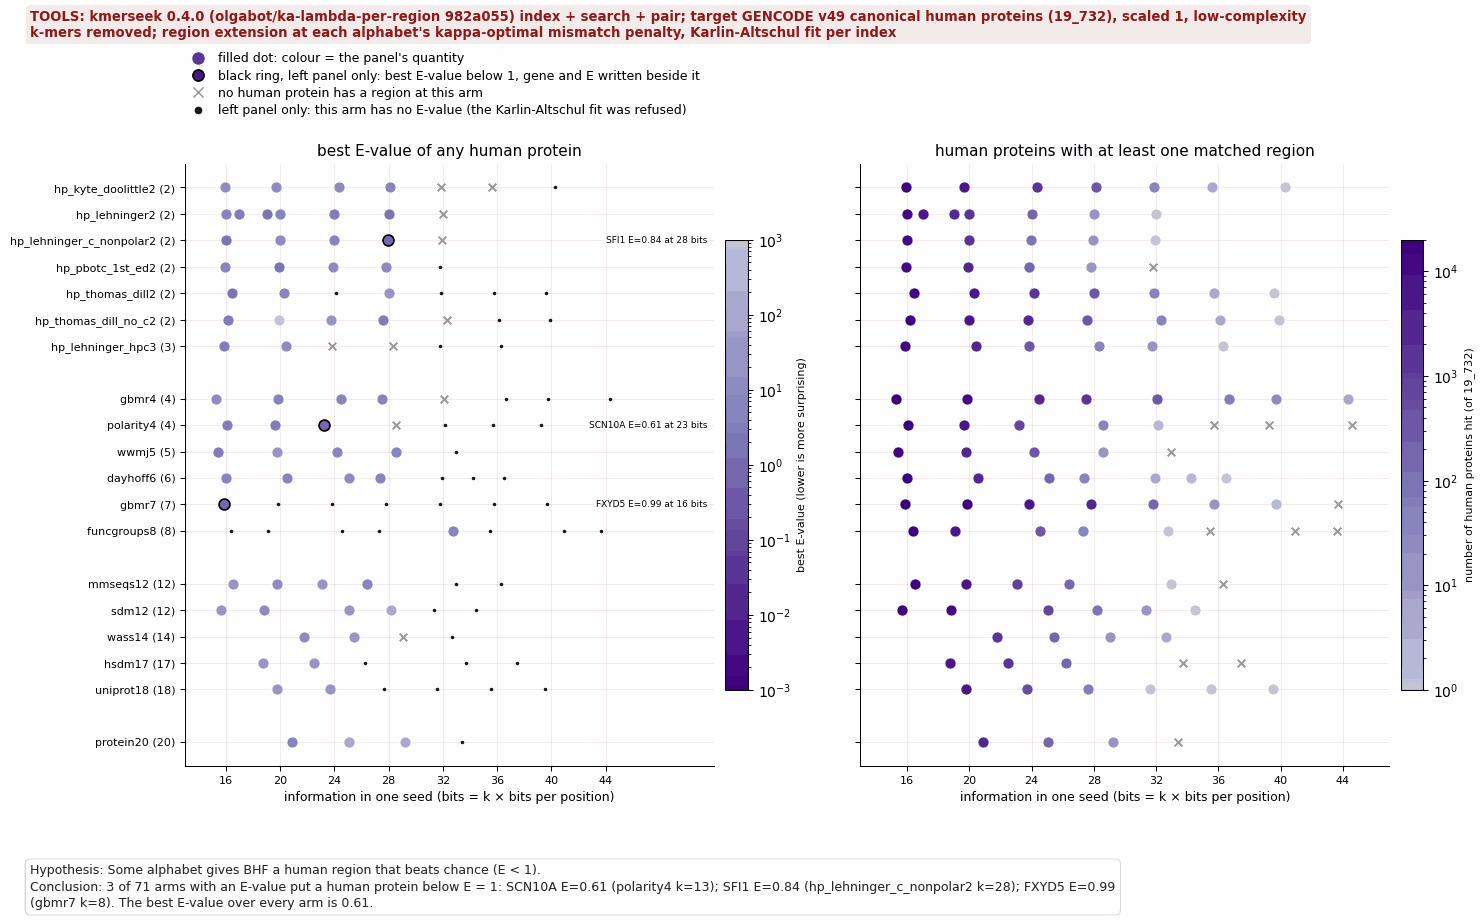

In [10]:
bhf = au.bhf_matrix(
    ranks,
    arms,
    FIG / "241_application_bhf.png",
    hypothesis="Some alphabet gives BHF a human region that beats chance (E < 1).",
    conclusion=(
        lambda e: (
            f"{e.filter(pl.col('best_value') < 1).height} of {e.filter(pl.col('fitted') == True).height} arms with an E-value put a human protein below E = 1: "
            + (
                "; ".join(
                    f"{r['top_gene']} E={r['best_value']:.2g} ({r['alphabet']} k={r['ksize']})"
                    for r in e.filter(pl.col("best_value") < 1)
                    .sort("best_value")
                    .iter_rows(named=True)
                )
                or "none"
            )
            + f". The best E-value over every arm is {e['best_value'].min():.2g}."
        )
    )(
        ranks.filter((pl.col("query") == "BHF") & (pl.col("metric") == "E-value")).join(
            arms.select("alphabet", "ksize", "fitted"), on=["alphabet", "ksize"]
        )
    ),
)
print(
    bhf.filter(pl.col("n_targets_BHF") > 0).sort("best_value", nulls_last=True).head(40)
)

## 9. Cross-check against PR #44's P66 ladder and random-protein control

[PR #44](https://github.com/seanome/2024-kmerseek-analysis/pull/44) (`analysis/ranking-metrics-p66/`)
ran P66 against CD47 pairwise down a k ladder for four alphabets and, as a control,
against 300 random human proteins of similar length (242-404 aa). Its reading: CD47
appears only at short k (hp_lehninger2 last at k=20 with 2 shared k-mers, polarity4 at
k=12, funcgroups8 at k=8, protein20 never), and at k=18 26 of the 300 random proteins
match or beat CD47's 4 shared k-mers (91st percentile), at k=20 24 of 300 beat its 2 (92nd).

This sweep's pairwise layer is the same measurement, and its rank of CD47 among every
human protein hit is the same control with all 19_732 proteins as the sample instead
of 300. The table joins the two ladders on the k values both ran; every shared count
should agree exactly, since both call `kmerseek pair` on the same two sequences.

shape: (12, 7)
┌───────────────┬─────┬───────────────────┬──────────────┬──────────────────┬─────────────┬───────┐
│ alphabet      ┆ k   ┆ shared_kmers_pr44 ┆ regions_pr44 ┆ shared_kmers_241 ┆ regions_241 ┆ agree │
│ ---           ┆ --- ┆ ---               ┆ ---          ┆ ---              ┆ ---         ┆ ---   │
│ str           ┆ i64 ┆ i64               ┆ i64          ┆ i64              ┆ i64         ┆ bool  │
╞═══════════════╪═════╪═══════════════════╪══════════════╪══════════════════╪═════════════╪═══════╡
│ funcgroups8   ┆ 6   ┆ 58                ┆ 42           ┆ 58               ┆ 42          ┆ true  │
│ funcgroups8   ┆ 10  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ funcgroups8   ┆ 12  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ funcgroups8   ┆ 15  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ hp_lehninger2 ┆ 20  ┆ 2                 ┆ 1            ┆ 2                ┆ 1      


PR #44's control, recomputed from its random_ladder.csv:
shape: (2, 4)
┌─────┬──────────┬───────────────────┬───────────────────────────────────────┐
│ k   ┆ n_random ┆ cd47_shared_kmers ┆ percent_of_random_proteins_cd47_beats │
│ --- ┆ ---      ┆ ---               ┆ ---                                   │
│ i64 ┆ u32      ┆ i64               ┆ f64                                   │
╞═════╪══════════╪═══════════════════╪═══════════════════════════════════════╡
│ 18  ┆ 300      ┆ 4                 ┆ 91.0                                  │
│ 20  ┆ 300      ┆ 2                 ┆ 92.0                                  │
└─────┴──────────┴───────────────────┴───────────────────────────────────────┘


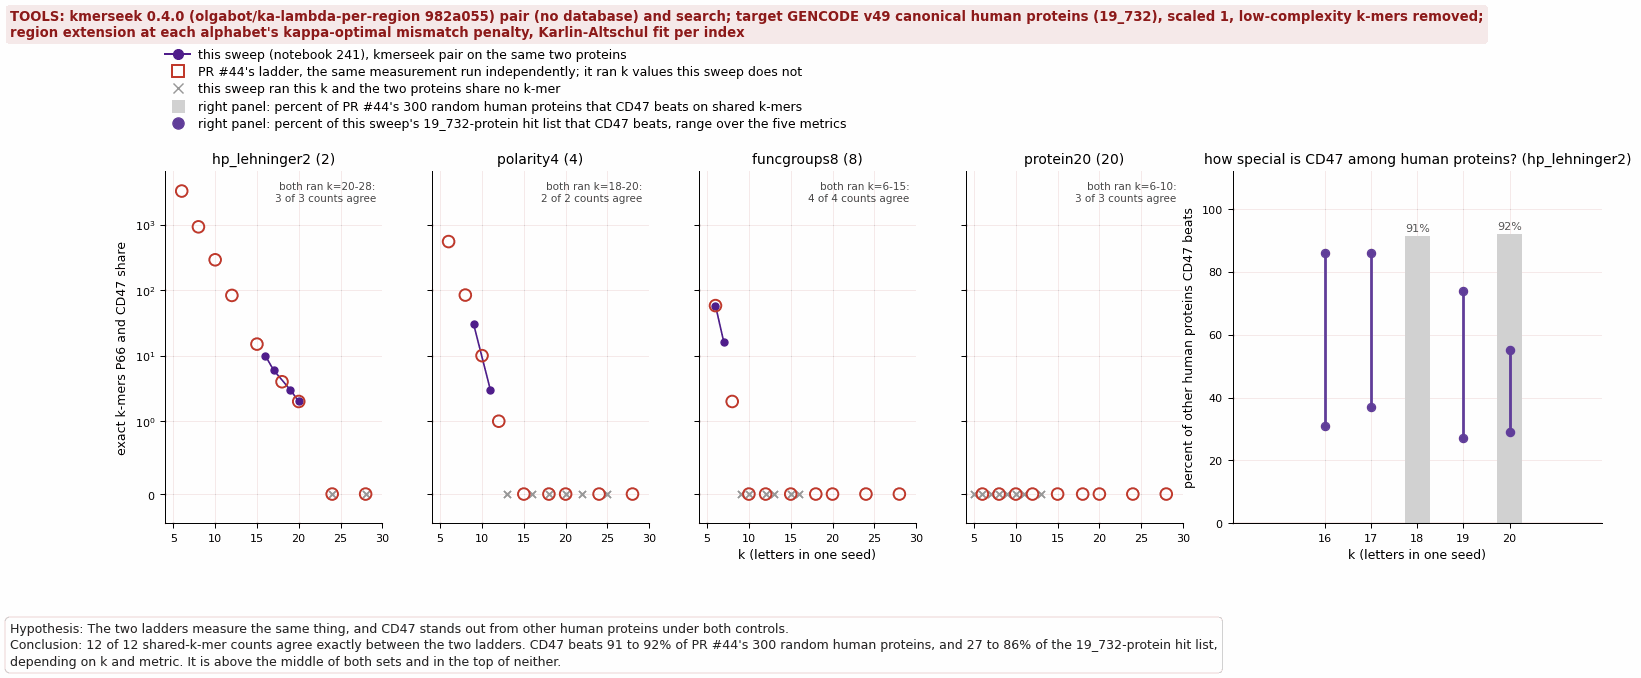

In [11]:
import json, subprocess


# PR #44's ladder, read from its branch so nothing is copied by hand.
def pr44_csv(name):
    ref = "origin/olgabot/ranking-metrics-and-p66"
    subprocess.run(
        ["git", "fetch", "-q", "origin", "olgabot/ranking-metrics-and-p66"], check=False
    )
    out = subprocess.run(
        ["git", "show", f"{ref}:analysis/ranking-metrics-p66/{name}"],
        capture_output=True,
        text=True,
    )
    if out.returncode != 0:
        print(f"PR #44's {name} not reachable: {out.stderr.strip()[:120]}")
        return None
    import io

    return pl.read_csv(io.StringIO(out.stdout))


theirs = pr44_csv("cd47_ladder.csv")
mine = []
for f in sorted((au.DATA / "pair").glob("*.P66.json")):
    a, k = f.name.replace(".P66.json", "").rsplit(".k", 1)
    d = json.loads(f.read_text())
    mine.append(
        {
            "alphabet": a,
            "k": int(k),
            "shared_kmers_241": len(d["shared_kmers"]),
            "regions_241": len(d["regions"]),
        }
    )
mine = pl.DataFrame(mine)
if theirs is not None:
    joined = (
        theirs.rename({"shared_kmers": "shared_kmers_pr44", "regions": "regions_pr44"})
        .join(mine, on=["alphabet", "k"], how="inner")
        .with_columns(
            (pl.col("shared_kmers_pr44") == pl.col("shared_kmers_241")).alias("agree")
        )
        .sort("alphabet", "k")
    )
    print(joined)
    print(
        f"\n{joined['agree'].sum()} of {joined.height} shared-k-mer counts agree on the k values both ladders ran"
    )
last_k = (
    mine.filter(pl.col("shared_kmers_241") > 0)
    .group_by("alphabet")
    .agg(pl.col("k").max().alias("last_k_with_shared_kmer_241"))
    .sort("alphabet")
)
print("\nlast k with any shared P66/CD47 k-mer, this sweep, all alphabets:")
print(last_k)

# CD47's rank among every human protein hit: the whole-proteome control.
cd47 = (
    ranks.filter(
        (pl.col("query") == "P66")
        & (pl.col("alphabet") == "hp_lehninger2")
        & pl.col("partner_found")
        & pl.col("metric").is_in(au.METRICS5)
    )
    .select("ksize", "bits", "metric", "rank", "n_targets")
    .with_columns(
        (100 * (1 - (pl.col("rank") - 1) / pl.col("n_targets")))
        .round(0)
        .alias("percentile_among_hits")
    )
    .sort("ksize", "metric")
)
print("\nCD47's rank among the human proteins hit by P66, hp_lehninger2:")
print(cd47)

# PR #44's 300 random human proteins of similar length, the same measurement.
control = pr44_csv("random_ladder.csv")
mine_hl = (
    {
        r["k"]: r["shared_kmers"]
        for r in theirs.filter(pl.col("alphabet") == "hp_lehninger2").iter_rows(
            named=True
        )
    }
    if theirs is not None
    else {
        r["k"]: r["shared_kmers_241"]
        for r in mine.filter(pl.col("alphabet") == "hp_lehninger2").iter_rows(
            named=True
        )
    }
)
if control is not None:
    beat = (
        control.group_by("k")
        .agg(pl.len().alias("n_random"), pl.col("shared_kmers").alias("counts"))
        .sort("k")
        .with_columns(
            pl.col("k").replace_strict(mine_hl, default=None).alias("cd47_shared_kmers")
        )
    )
    beat = beat.with_columns(
        pl.struct("counts", "cd47_shared_kmers")
        .map_elements(
            lambda d: (
                None
                if d["cd47_shared_kmers"] is None
                else round(
                    100.0
                    * sum(c < d["cd47_shared_kmers"] for c in d["counts"])
                    / len(d["counts"])
                )
            ),
            return_dtype=pl.Float64,
        )
        .alias("percent_of_random_proteins_cd47_beats")
    ).drop("counts")
    print("\nPR #44's control, recomputed from its random_ladder.csv:")
    print(beat)

au.pr44_crosscheck_figure(
    mine,
    theirs,
    control,
    cd47,
    FIG / "241_pr44_crosscheck.png",
    hypothesis="The two ladders measure the same thing, and CD47 stands out from other human proteins under both controls.",
    conclusion=(
        f"{joined['agree'].sum()} of {joined.height} shared-k-mer counts agree exactly between the two ladders. "
        if theirs is not None
        else ""
    )
    + (
        f"CD47 beats {beat['percent_of_random_proteins_cd47_beats'].min():.0f} to "
        f"{beat['percent_of_random_proteins_cd47_beats'].max():.0f}% of PR #44's 300 random human proteins, and "
        if control is not None
        else ""
    )
    + f"{cd47['percentile_among_hits'].min():.0f} to {cd47['percentile_among_hits'].max():.0f}% of the "
    f"19_732-protein hit list, depending on k and metric. It is above the middle of both sets and in the top of neither.",
)

## 10. Why so few regions have an E-value

An E-value says how many matches this good the search expects to see by chance. Getting
one needs a number called lambda, the scale that turns a match's raw score into the
units chance is counted in. No lambda, no E-value.

**A match has to lose ground on average when it is only chance.** Each matched position
scores +1 and each mismatched position scores −C, where C is the mismatch penalty. If
the two sequences were unrelated, a position would match by luck with probability p, the
chance that two random residues of this proteome fall in the same class. So one position
of a chance match scores p − C (1 − p) on average. That number has to be **below zero**.
Below zero, a chance match loses score the longer it runs, high scores stay rare, and
lambda exists. At or above zero, a chance match keeps gaining score just by running
longer, no score is ever surprising, and there is no lambda and no E-value at any k.
That is what the right panel shows: bars to the left of the red line are fine, bars
touching or crossing it mean the alphabet can never produce an E-value.

**Even where lambda exists for the alphabet, it can come out as zero for a region.**
This kmerseek build solves lambda from each region's own two spans. It counts the
classes in the query span and in the target span. From those counts it takes u: pick one
random position in each span, and u is the chance the two fall in the same class. A region with u at or above C / (1 + C) gets lambda 0, so
it has no E-value. With the kappa-optimal penalties that limit is 0.60 for hp_lehninger2
(C = 1.51) but only 0.12 to 0.19 for the 12- to 20-class alphabets (C = 0.14 to 0.24).

The limit is on u, not on the region's identity. Every one of the 8_295_664 regions in
this run has identity above C / (1 + C), and 7_240_393 of them have lambda 0. Two
dayhoff6 k=7 regions (C = 0.41, limit 0.29) with about the same identity show the
difference. Coordinates are 0-based, end excluded.

Ced9 48-68 against BCL2 58-78: 4 of 20 residues identical, 13 of 20 classes (0.65),
u = 0.430, lambda 0, no E-value. Both spans are mostly class b.

```
Ced9  PSPSRQASTRRMSIGESIDG
      |  ||    |
BCL2  PAASRDPVARTSPLQTPAAP

Ced9  bbbbdcbbbddebebcbecb
      ||||||| ||  ||  |  |
BCL2  bbbbdcbebdbbbecbbbbb
```

P66 314-329 against CD47 105-120: 3 of 15 residues identical, 10 of 15 classes (0.67),
u = 0.258, lambda 0.174 (as reported in region_ka_lambda, after kmerseek's database
correction), E = 37_882.

```
P66   ISKAANFKKETPSDP
       |   |   |
CD47  VSHTGNYTCEVTELT

P66   ebdbbcfddcbbbcb
      |||||||  | |  |
CD47  ebdbbcfbacebceb
```

The 12- to 20-class alphabets lose almost every extended region (88 to 98%). The regions
that lose their E-value lean toward the closer matches: in every alphabet their median
identity is the same as or higher than that of the regions that keep one (sdm12: 0.86
against 0.64).

The two problems have one root: the penalty C is derived from kappa assuming every class
holds the same share of residues (1 / classes). On this proteome the real chance match
probability is 0.39 for gbmr7 (one class holds most residues), 0.48 for
hp_lehninger_hpc3 and 0.40 for gbmr4, all far above 1 / classes, which is why their bars
sit at or past zero. The fix is to derive C from the measured class shares (p = sum of
p_i squared) instead.

shape: (19, 4)
┌──────────────────────────┬──────────────┬─────────┬─────────┐
│ alphabet                 ┆ chance_drift ┆ p_match ┆ penalty │
│ ---                      ┆ ---          ┆ ---     ┆ ---     │
│ str                      ┆ f64          ┆ f64     ┆ f64     │
╞══════════════════════════╪══════════════╪═════════╪═════════╡
│ gbmr7                    ┆ 0.19876      ┆ 0.393   ┆ 0.32    │
│ hp_lehninger_hpc3        ┆ 0.02573      ┆ 0.479   ┆ 0.87    │
│ gbmr4                    ┆ -0.00033     ┆ 0.401   ┆ 0.67    │
│ polarity4                ┆ -0.02564     ┆ 0.334   ┆ 0.54    │
│ sdm12                    ┆ -0.06516     ┆ 0.141   ┆ 0.24    │
│ wass14                   ┆ -0.06587     ┆ 0.089   ┆ 0.17    │
│ uniprot18                ┆ -0.0672      ┆ 0.072   ┆ 0.15    │
│ hsdm17                   ┆ -0.07144     ┆ 0.092   ┆ 0.18    │
│ protein20                ┆ -0.07274     ┆ 0.059   ┆ 0.14    │
│ dayhoff6                 ┆ -0.08006     ┆ 0.234   ┆ 0.41    │
│ mmseqs12               

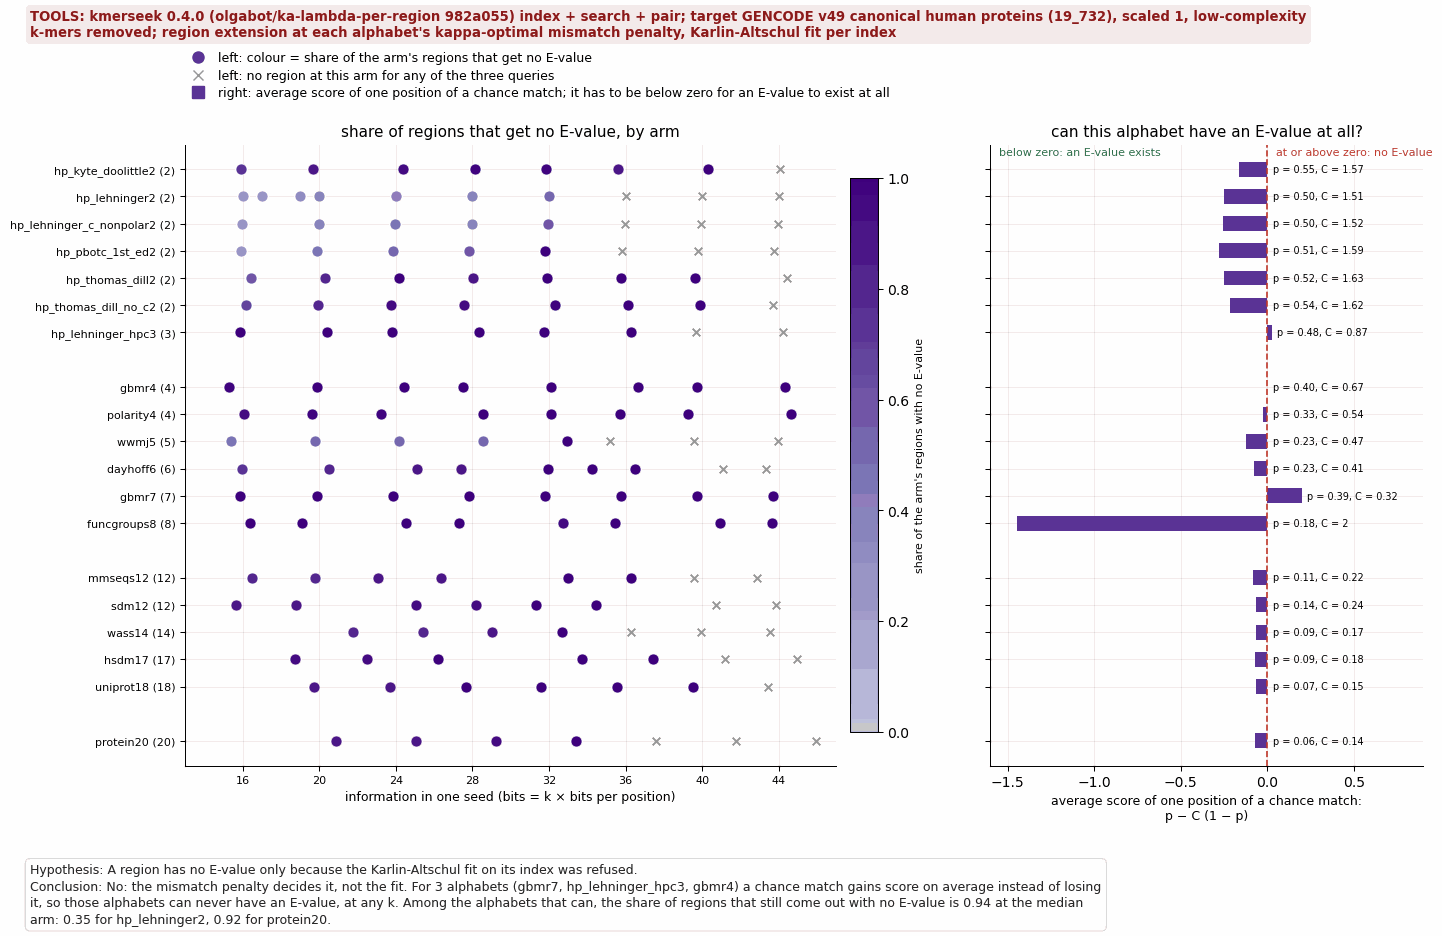

In [12]:
lz = au.lambda_zero_figure(
    arms,
    FIG / "241_no_evalue_mechanism.png",
    hypothesis="A region has no E-value only because the Karlin-Altschul fit on its index was refused.",
    conclusion=(
        lambda a: (
            f"No: the mismatch penalty decides it, not the fit. For "
            f"{a.filter(pl.col('chance_drift') >= -0.001)['alphabet'].n_unique()} alphabets "
            f"({', '.join(a.filter(pl.col('chance_drift') >= -0.001).sort('chance_drift', descending=True)['alphabet'])}) "
            f"a chance match gains score on average instead of losing it, so those alphabets can never have an E-value, at any k. "
            f"Among the alphabets that can, the share of regions that still come out with no E-value is "
            f"{arms.join(a.filter(pl.col('chance_drift') < -0.001).select('alphabet'), on='alphabet')['frac_lambda_zero'].median():.2f} at the median arm: "
            f"{arms.filter(pl.col('alphabet') == 'hp_lehninger2')['frac_lambda_zero'].mean():.2f} for hp_lehninger2, "
            f"{arms.filter(pl.col('alphabet') == 'protein20')['frac_lambda_zero'].mean():.2f} for protein20."
        )
    )(arms.group_by("alphabet").agg(pl.col("chance_drift").first())),
)
print(lz)
print(
    arms.group_by("alphabet")
    .agg(
        pl.col("frac_lambda_zero").mean().round(2).alias("mean_share_no_evalue"),
        (pl.col("frac_lambda_zero") >= 0.999).sum().alias("arms_with_no_evalue_at_all"),
        pl.len().alias("arms"),
    )
    .sort("mean_share_no_evalue", descending=True)
)

## 11. Conclusions

**No alphabet and no metric puts either known partner near the top of the human
proteome.** BCL2 is among the hits for 13 of 19 alphabets when Ced9 is the query, and its
best rank over every k and every metric is 213 of 18_064 proteins hit (polarity4, mean
IDF, k=9, 16 bits); under hp_lehninger2 it is 1_204 of 3_195 (mean IDF, k=19). CD47 is
among the hits for 16 of 19 alphabets when P66 is the query, best 166 of 18_775
(hp_lehninger_hpc3, E-value, k=14, 16 bits). Both partners are only in view below about
25 bits per seed, where thousands of human proteins are in view with them, and both
disappear before the seed carries the ~32 bits an E-value of 1 needs on this database.
Their own best E-values are 1_955 (BCL2, wwmj5 k=9) and 707 (CD47).

**And that best rank is not better than luck.** The 213 is the smallest of 102 ranks,
one per alphabet, k and metric. Draw a human protein at random from each of those same
102 hit lists and keep the smallest rank, and it comes out at 42 (middle 90%: 4 to 176);
a random protein does as well or better than BCL2 in 97% of 20_000 draws, and better than
CD47 in 90%. At the level of the whole sweep the known partner is not separable from an
arbitrary protein the search happened to hit.

**No ranking metric rescues it, and one of the eleven was lying.** Across all eleven
metrics the search writes, the best the partner ever reaches is the top 1.18% for BCL2
(mean IDF, polarity4 k=9) and the top 0.88% for CD47 (E-value, hp_lehninger_hpc3 k=14).
The top 10 of the human proteome is the top 0.05%, so the best metric lands about 20
times further down the list. `region_ka_bits` looked like the exception, putting BCL2 at
rank 1 of 18_303 under gbmr7 k=10, but that arm has no lambda, so the bit score is 0 for
every region and 18_302 proteins were tied with it. The collector now leaves the bit
score empty where there is no lambda, the same as the E-value; after that it ranks BCL2
1_352 of 5_153, the same as the E-value it is a transform of.

**The 20-letter alphabet is not the answer either.** protein20 and uniprot18 never have
BCL2 or CD47 among the hits at any k; wass14 never has CD47; hsdm17, sdm12 and the two
Thomas-Dill 2-letter alphabets never have BCL2. The coarse alphabets keep the pair in
view a few bits longer, at the price of a larger crowd.

**The pairwise layer agrees with PR #44** on every one of the 12 k values both ladders
ran, and this sweep's rank among 19_732 proteins is the whole-proteome form of PR #44's
300-random-protein control: under hp_lehninger2 and the five metrics, CD47 sits between
the 27th and the 86th percentile of the proteins P66 hits, never in the top 5%.

**BHF gets nothing that beats chance.** Of the 71 arms with an E-value, 3 put a human
protein just under E = 1 (SCN10A 0.61 at polarity4 k=13, SFI1 0.84 at hp_lehninger_c_nonpolar2
k=28, FXYD5 0.99 at gbmr7 k=8), which is what 71 independent searches are expected to
produce by chance.

**Two things about the E-value itself, which matter beyond these three proteins.**
(1) The per-region lambda gives E = inf to every region whose u is at or above
C / (1 + C). u is the chance that one random position from each of the region's two spans
falls in the same class. With the kappa penalties that removes 35% of hp_lehninger2 regions and
88 to 98% for the 12- to 20-class alphabets, and the regions it removes have the same or
a higher median identity than the ones it keeps. (2) The kappa-optimal penalty assumes equal class shares; on this proteome
gbmr7, hp_lehninger_hpc3 and gbmr4 have a chance match rate high enough that a chance
position scores at or above zero, so no lambda exists for them at any k. 81 of 152 arms
ended without a Karlin-Altschul fit; above about 30 bits both curves run out of score
bins, and below it the many-class alphabets have curves too narrow to hold four bins
however many queries are searched.

**What this changes.** The E-value, mean IDF, tf-idf, enrichment and Poisson p-value
all rank the known partner in the hundreds to thousands, because the matched region
carries 16 to 25 bits against a background that needs 32. Ranking metrics cannot fix a
seed that is too short; what the gold standard needs is a longer region, which means
extension or chaining whose regions keep u below C / (1 + C), and a penalty derived
from the real class shares so that an E-value exists for it.